In [1]:
!pip install -q ultralytics opencv-python matplotlib pandas numpy tqdm pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import os
import cv2
import time
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import torch
import shutil
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")

print("Main folders inside /kaggle/input:")
for item in INPUT_ROOT.iterdir():
    print(item)

print("\nSecond-level folders/files:")
for main in INPUT_ROOT.iterdir():
    if main.is_dir():
        print("\nMAIN:", main)
        try:
            for sub in main.iterdir():
                print("  ", sub)
        except Exception as e:
            print("Could not read:", e)

Main folders inside /kaggle/input:
/kaggle/input/datasets
/kaggle/input/notebooks

Second-level folders/files:

MAIN: /kaggle/input/datasets
   /kaggle/input/datasets/banuprasadb

MAIN: /kaggle/input/notebooks
   /kaggle/input/notebooks/mdrifadhossain


In [4]:
def find_best_pt(input_root):
    best_paths = list(input_root.rglob("best.pt"))

    if len(best_paths) > 0:
        return best_paths[0]

    zip_files = list(input_root.rglob("*.zip"))

    print("No best.pt found directly.")
    print("Zip files found:")
    for z in zip_files:
        print(z)

    for zip_path in zip_files:
        extract_dir = WORK_ROOT / "extracted_previous_output"
        extract_dir.mkdir(parents=True, exist_ok=True)

        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        best_paths = list(extract_dir.rglob("best.pt"))

        if len(best_paths) > 0:
            return best_paths[0]

    return None


BEST_MODEL_PATH = find_best_pt(INPUT_ROOT)

if BEST_MODEL_PATH is None:
    raise FileNotFoundError("best.pt not found. Add previous notebook output or upload best.pt.")

print("Best model found:", BEST_MODEL_PATH)

Best model found: /kaggle/input/notebooks/mdrifadhossain/drone-train-ant/runs/yolo_human_car_detector/weights/best.pt


In [5]:
def find_best_pt(input_root):
    best_paths = list(input_root.rglob("best.pt"))

    if len(best_paths) > 0:
        return best_paths[0]

    zip_files = list(input_root.rglob("*.zip"))

    print("No best.pt found directly.")
    print("Zip files found:")
    for z in zip_files:
        print(z)

    for zip_path in zip_files:
        extract_dir = WORK_ROOT / "extracted_previous_output"
        extract_dir.mkdir(parents=True, exist_ok=True)

        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        best_paths = list(extract_dir.rglob("best.pt"))

        if len(best_paths) > 0:
            return best_paths[0]

    return None


BEST_MODEL_PATH = find_best_pt(INPUT_ROOT)

if BEST_MODEL_PATH is None:
    raise FileNotFoundError("best.pt not found. Add previous notebook output or upload best.pt.")

print("Best model found:", BEST_MODEL_PATH)

Best model found: /kaggle/input/notebooks/mdrifadhossain/drone-train-ant/runs/yolo_human_car_detector/weights/best.pt


In [6]:
detector = YOLO(str(BEST_MODEL_PATH))

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
NORMAL_CONF = 0.25

# For test output, use stricter tiled confidence to reduce false/duplicate boxes
TILED_CONF = 0.30

TILE_SIZE = 512
TILE_OVERLAP = 0.20
TILE_IMGSZ = 640
NMS_IOU = 0.30

print("NORMAL_CONF:", NORMAL_CONF)
print("TILED_CONF:", TILED_CONF)
print("TILE_SIZE:", TILE_SIZE)
print("TILE_OVERLAP:", TILE_OVERLAP)
print("TILE_IMGSZ:", TILE_IMGSZ)
print("NMS_IOU:", NMS_IOU)

NORMAL_CONF: 0.25
TILED_CONF: 0.3
TILE_SIZE: 512
TILE_OVERLAP: 0.2
TILE_IMGSZ: 640
NMS_IOU: 0.3


In [8]:
def calculate_iou(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0])
    y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2])
    y2 = np.minimum(box[3], boxes[:, 3])

    inter_w = np.maximum(0, x2 - x1)
    inter_h = np.maximum(0, y2 - y1)
    inter_area = inter_w * inter_h

    box_area = max(0, box[2] - box[0]) * max(0, box[3] - box[1])
    boxes_area = np.maximum(0, boxes[:, 2] - boxes[:, 0]) * np.maximum(0, boxes[:, 3] - boxes[:, 1])

    union_area = box_area + boxes_area - inter_area + 1e-6
    return inter_area / union_area


def nms_per_class(boxes, scores, classes, iou_threshold=0.30):
    if len(boxes) == 0:
        return np.array([]), np.array([]), np.array([])

    boxes = np.array(boxes)
    scores = np.array(scores)
    classes = np.array(classes)

    final_indices = []

    for cls in np.unique(classes):
        cls_indices = np.where(classes == cls)[0]
        cls_boxes = boxes[cls_indices]
        cls_scores = scores[cls_indices]

        order = np.argsort(cls_scores)[::-1]

        while len(order) > 0:
            current = order[0]
            final_indices.append(cls_indices[current])

            if len(order) == 1:
                break

            ious = calculate_iou(cls_boxes[current], cls_boxes[order[1:]])
            keep = np.where(ious < iou_threshold)[0]
            order = order[keep + 1]

    final_indices = np.array(final_indices)

    return boxes[final_indices], scores[final_indices], classes[final_indices]


def draw_boxes_and_count(image_path, boxes, scores, classes, output_path, title_text):
    image = cv2.imread(str(image_path))

    human_count = 0
    car_count = 0

    for box, score, cls_id in zip(boxes, scores, classes):
        cls_id = int(cls_id)
        x1, y1, x2, y2 = box.astype(int)

        if cls_id == 0:
            human_count += 1
            color = (0, 255, 0)
            label = f"human {score:.2f}"
        elif cls_id == 1:
            car_count += 1
            color = (255, 0, 0)
            label = f"car {score:.2f}"
        else:
            continue

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, label, (x1, max(y1 - 5, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    overlay_text = f"{title_text} | Humans: {human_count} | Cars: {car_count}"

    cv2.rectangle(image, (15, 15), (min(1000, image.shape[1] - 10), 75), (0, 0, 0), -1)
    cv2.putText(image, overlay_text, (25, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

    cv2.imwrite(str(output_path), image)

    return human_count, car_count


def show_images_from_folder(folder, title, max_images=6):
    image_paths = list(Path(folder).glob("*.jpg")) + list(Path(folder).glob("*.png"))

    if len(image_paths) == 0:
        print("No images found in", folder)
        return

    image_paths = image_paths[:max_images]

    plt.figure(figsize=(16, 10))

    for i, img_path in enumerate(image_paths):
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(img_path.name)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [9]:
def normal_yolo_detect(image_path, model, conf=NORMAL_CONF, imgsz=960):
    results = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=imgsz,
        verbose=False
    )

    result = results[0]

    boxes = []
    scores = []
    classes = []

    for box in result.boxes:
        cls_id = int(box.cls[0])
        score = float(box.conf[0])
        xyxy = box.xyxy[0].cpu().numpy()

        boxes.append(xyxy)
        scores.append(score)
        classes.append(cls_id)

    if len(boxes) == 0:
        return np.array([]), np.array([]), np.array([])

    return np.array(boxes), np.array(scores), np.array(classes)

In [10]:
def get_tile_starts(length, tile_size, stride):
    if length <= tile_size:
        return [0]

    starts = list(range(0, length - tile_size + 1, stride))
    last_start = length - tile_size

    if starts[-1] != last_start:
        starts.append(last_start)

    return starts


def tiled_yolo_detect(
    image_path,
    model,
    tile_size=TILE_SIZE,
    overlap=TILE_OVERLAP,
    conf=TILED_CONF,
    imgsz=TILE_IMGSZ,
    nms_iou=NMS_IOU,
    allowed_classes=None
):
    image = cv2.imread(str(image_path))
    h, w, _ = image.shape

    stride = int(tile_size * (1 - overlap))
    stride = max(1, stride)

    all_boxes = []
    all_scores = []
    all_classes = []

    y_starts = get_tile_starts(h, tile_size, stride)
    x_starts = get_tile_starts(w, tile_size, stride)

    for y1 in y_starts:
        for x1 in x_starts:
            x2 = min(x1 + tile_size, w)
            y2 = min(y1 + tile_size, h)

            tile = image[y1:y2, x1:x2]

            if tile.shape[0] < 64 or tile.shape[1] < 64:
                continue

            results = model.predict(
                source=tile,
                conf=conf,
                imgsz=imgsz,
                verbose=False
            )

            result = results[0]

            for box in result.boxes:
                cls_id = int(box.cls[0])

                if allowed_classes is not None and cls_id not in allowed_classes:
                    continue

                score = float(box.conf[0])
                xyxy = box.xyxy[0].cpu().numpy()

                xyxy[0] += x1
                xyxy[1] += y1
                xyxy[2] += x1
                xyxy[3] += y1

                xyxy[0] = max(0, min(xyxy[0], w - 1))
                xyxy[1] = max(0, min(xyxy[1], h - 1))
                xyxy[2] = max(0, min(xyxy[2], w - 1))
                xyxy[3] = max(0, min(xyxy[3], h - 1))

                all_boxes.append(xyxy)
                all_scores.append(score)
                all_classes.append(cls_id)

    if len(all_boxes) == 0:
        return np.array([]), np.array([]), np.array([])

    final_boxes, final_scores, final_classes = nms_per_class(
        all_boxes,
        all_scores,
        all_classes,
        iou_threshold=nms_iou
    )

    return final_boxes, final_scores, final_classes

In [11]:
def class_aware_hybrid_detect(image_path, model):
    normal_boxes, normal_scores, normal_classes = normal_yolo_detect(
        image_path=image_path,
        model=model,
        conf=NORMAL_CONF,
        imgsz=960
    )

    tiled_human_boxes, tiled_human_scores, tiled_human_classes = tiled_yolo_detect(
        image_path=image_path,
        model=model,
        tile_size=TILE_SIZE,
        overlap=TILE_OVERLAP,
        conf=TILED_CONF,
        imgsz=TILE_IMGSZ,
        nms_iou=NMS_IOU,
        allowed_classes=[0]
    )

    final_boxes = []
    final_scores = []
    final_classes = []

    # Keep normal cars only
    for box, score, cls_id in zip(normal_boxes, normal_scores, normal_classes):
        if int(cls_id) == 1:
            final_boxes.append(box)
            final_scores.append(score)
            final_classes.append(cls_id)

    # Add normal humans
    for box, score, cls_id in zip(normal_boxes, normal_scores, normal_classes):
        if int(cls_id) == 0:
            final_boxes.append(box)
            final_scores.append(score)
            final_classes.append(cls_id)

    # Add tiled humans
    for box, score, cls_id in zip(tiled_human_boxes, tiled_human_scores, tiled_human_classes):
        final_boxes.append(box)
        final_scores.append(score)
        final_classes.append(cls_id)

    if len(final_boxes) == 0:
        return np.array([]), np.array([]), np.array([])

    final_boxes, final_scores, final_classes = nms_per_class(
        final_boxes,
        final_scores,
        final_classes,
        iou_threshold=NMS_IOU
    )

    return final_boxes, final_scores, final_classes

In [12]:
# DEFINE DATASET PATHS FIRST

from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")

DATA_ROOT = Path("/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset")

TRAIN_DIR = DATA_ROOT / "VisDrone2019-DET-train"
VAL_DIR = DATA_ROOT / "VisDrone2019-DET-val"
TEST_DEV_DIR = DATA_ROOT / "VisDrone2019-DET-test-dev"

TRAIN_IMG_DIR = TRAIN_DIR / "images"
TRAIN_LBL_DIR = TRAIN_DIR / "labels"

VAL_IMG_DIR = VAL_DIR / "images"
VAL_LBL_DIR = VAL_DIR / "labels"

TEST_IMG_DIR = TEST_DEV_DIR / "images"
TEST_LBL_DIR = TEST_DEV_DIR / "labels"

print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TEST_IMG_DIR exists:", TEST_IMG_DIR.exists())
print("TEST_LBL_DIR exists:", TEST_LBL_DIR.exists())

DATA_ROOT: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
DATA_ROOT exists: True
TEST_IMG_DIR exists: True
TEST_LBL_DIR exists: True


In [13]:
test_images = list(TEST_IMG_DIR.glob("*.jpg"))

In [14]:
def find_visdrone_root(input_root):
    candidates = []

    for path in input_root.rglob("*"):
        if path.is_dir():
            train_dir = path / "VisDrone2019-DET-train"
            val_dir = path / "VisDrone2019-DET-val"
            test_dir = path / "VisDrone2019-DET-test-dev"

            if train_dir.exists() and val_dir.exists() and test_dir.exists():
                candidates.append(path)

    return candidates


dataset_candidates = find_visdrone_root(INPUT_ROOT)

print("Dataset candidates:")
for c in dataset_candidates:
    print(c)

if len(dataset_candidates) == 0:
    raise FileNotFoundError("VisDrone dataset root not found.")

DATA_ROOT = dataset_candidates[0]

TRAIN_DIR = DATA_ROOT / "VisDrone2019-DET-train"
VAL_DIR = DATA_ROOT / "VisDrone2019-DET-val"
TEST_DEV_DIR = DATA_ROOT / "VisDrone2019-DET-test-dev"

TRAIN_IMG_DIR = TRAIN_DIR / "images"
TRAIN_LBL_DIR = TRAIN_DIR / "labels"

VAL_IMG_DIR = VAL_DIR / "images"
VAL_LBL_DIR = VAL_DIR / "labels"

TEST_IMG_DIR = TEST_DEV_DIR / "images"
TEST_LBL_DIR = TEST_DEV_DIR / "labels"

print("DATA_ROOT:", DATA_ROOT)
print("TEST_IMG_DIR exists:", TEST_IMG_DIR.exists())
print("TEST_LBL_DIR exists:", TEST_LBL_DIR.exists())

Dataset candidates:
/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
DATA_ROOT: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
TEST_IMG_DIR exists: True
TEST_LBL_DIR exists: True


In [15]:
test_images = list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.png")) + list(TEST_IMG_DIR.glob("*.jpeg"))

print("Total test images:", len(test_images))

# Use 20 sample images first. Later you can increase this number.
sample_test_images = random.sample(test_images, min(20, len(test_images)))

print("Selected test images:", len(sample_test_images))

Total test images: 1610
Selected test images: 20


In [16]:
OUTPUT_NORMAL = WORK_ROOT / "test_output_1_normal_yolo"
OUTPUT_HYBRID = WORK_ROOT / "test_output_2_class_aware_hybrid"
OUTPUT_TILED = WORK_ROOT / "test_output_3_always_tiled_yolo"
OUTPUT_DENSITY = WORK_ROOT / "test_output_4_density_heatmap"

for folder in [OUTPUT_NORMAL, OUTPUT_HYBRID, OUTPUT_TILED, OUTPUT_DENSITY]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders created.")

Output folders created.


In [17]:
normal_records = []

for img_path in tqdm(sample_test_images):
    start = time.time()

    boxes, scores, classes = normal_yolo_detect(
        image_path=img_path,
        model=detector,
        conf=NORMAL_CONF,
        imgsz=960
    )

    output_path = OUTPUT_NORMAL / f"normal_{img_path.name}"

    humans, cars = draw_boxes_and_count(
        image_path=img_path,
        boxes=boxes,
        scores=scores,
        classes=classes,
        output_path=output_path,
        title_text="Test: Normal YOLO"
    )

    normal_records.append({
        "image": img_path.name,
        "humans": humans,
        "cars": cars,
        "time_sec": time.time() - start,
        "output_path": str(output_path)
    })

normal_df = pd.DataFrame(normal_records)
normal_df.to_csv(WORK_ROOT / "test_normal_counts.csv", index=False)

normal_df

100%|██████████| 20/20 [00:05<00:00,  3.84it/s]


,image,humans,cars,time_sec,output_path
0,9999938_00000_d_0000217.jpg,218,26,3.588861,/kaggle/working/test_output_1_normal_yolo/norm...
1,9999952_00000_d_0000228.jpg,1,3,0.082789,/kaggle/working/test_output_1_normal_yolo/norm...
2,9999952_00000_d_0000080.jpg,0,23,0.082773,/kaggle/working/test_output_1_normal_yolo/norm...
3,9999938_00000_d_0000365.jpg,0,14,0.096403,/kaggle/working/test_output_1_normal_yolo/norm...
4,0000353_04500_d_0000197.jpg,16,50,0.098655,/kaggle/working/test_output_1_normal_yolo/norm...
5,9999952_00000_d_0000277.jpg,2,19,0.095029,/kaggle/working/test_output_1_normal_yolo/norm...
6,9999976_00000_d_0000001.jpg,15,1,0.085710,/kaggle/working/test_output_1_normal_yolo/norm...
7,9999941_00000_d_0000008.jpg,1,9,0.092179,/kaggle/working/test_output_1_normal_yolo/norm...
8,9999938_00000_d_0000135.jpg,14,11,0.078187,/kaggle/working/test_output_1_normal_yolo/norm...
9,9999941_00000_d_0000006.jpg,12,2,0.075146,/kaggle/working/test_output_1_normal_yolo/norm...


In [18]:
hybrid_records = []

for img_path in tqdm(sample_test_images):
    start = time.time()

    boxes, scores, classes = class_aware_hybrid_detect(
        image_path=img_path,
        model=detector
    )

    output_path = OUTPUT_HYBRID / f"hybrid_{img_path.name}"

    humans, cars = draw_boxes_and_count(
        image_path=img_path,
        boxes=boxes,
        scores=scores,
        classes=classes,
        output_path=output_path,
        title_text="Test: Class-Aware Hybrid"
    )

    hybrid_records.append({
        "image": img_path.name,
        "humans": humans,
        "cars": cars,
        "time_sec": time.time() - start,
        "output_path": str(output_path)
    })

hybrid_df = pd.DataFrame(hybrid_records)
hybrid_df.to_csv(WORK_ROOT / "test_hybrid_counts.csv", index=False)

hybrid_df

100%|██████████| 20/20 [00:05<00:00,  3.55it/s]


,image,humans,cars,time_sec,output_path
0,9999938_00000_d_0000217.jpg,238,26,0.397779,/kaggle/working/test_output_2_class_aware_hybr...
1,9999952_00000_d_0000228.jpg,1,3,0.258374,/kaggle/working/test_output_2_class_aware_hybr...
2,9999952_00000_d_0000080.jpg,0,23,0.257358,/kaggle/working/test_output_2_class_aware_hybr...
3,9999938_00000_d_0000365.jpg,0,14,0.267765,/kaggle/working/test_output_2_class_aware_hybr...
4,0000353_04500_d_0000197.jpg,15,49,0.269552,/kaggle/working/test_output_2_class_aware_hybr...
5,9999952_00000_d_0000277.jpg,5,18,0.253613,/kaggle/working/test_output_2_class_aware_hybr...
6,9999976_00000_d_0000001.jpg,16,1,0.257157,/kaggle/working/test_output_2_class_aware_hybr...
7,9999941_00000_d_0000008.jpg,12,9,0.279476,/kaggle/working/test_output_2_class_aware_hybr...
8,9999938_00000_d_0000135.jpg,20,11,0.262661,/kaggle/working/test_output_2_class_aware_hybr...
9,9999941_00000_d_0000006.jpg,11,2,0.259457,/kaggle/working/test_output_2_class_aware_hybr...


In [19]:
tiled_records = []

for img_path in tqdm(sample_test_images):
    start = time.time()

    boxes, scores, classes = tiled_yolo_detect(
        image_path=img_path,
        model=detector,
        tile_size=TILE_SIZE,
        overlap=TILE_OVERLAP,
        conf=TILED_CONF,
        imgsz=TILE_IMGSZ,
        nms_iou=NMS_IOU,
        allowed_classes=None
    )

    output_path = OUTPUT_TILED / f"tiled_{img_path.name}"

    humans, cars = draw_boxes_and_count(
        image_path=img_path,
        boxes=boxes,
        scores=scores,
        classes=classes,
        output_path=output_path,
        title_text="Test: Always Tiled YOLO"
    )

    tiled_records.append({
        "image": img_path.name,
        "humans": humans,
        "cars": cars,
        "time_sec": time.time() - start,
        "output_path": str(output_path)
    })

tiled_df = pd.DataFrame(tiled_records)
tiled_df.to_csv(WORK_ROOT / "test_tiled_counts.csv", index=False)

tiled_df

100%|██████████| 20/20 [00:04<00:00,  4.24it/s]


,image,humans,cars,time_sec,output_path
0,9999938_00000_d_0000217.jpg,178,24,0.261018,/kaggle/working/test_output_3_always_tiled_yol...
1,9999952_00000_d_0000228.jpg,1,4,0.210174,/kaggle/working/test_output_3_always_tiled_yol...
2,9999952_00000_d_0000080.jpg,0,24,0.217372,/kaggle/working/test_output_3_always_tiled_yol...
3,9999938_00000_d_0000365.jpg,0,14,0.221941,/kaggle/working/test_output_3_always_tiled_yol...
4,0000353_04500_d_0000197.jpg,14,51,0.229736,/kaggle/working/test_output_3_always_tiled_yol...
5,9999952_00000_d_0000277.jpg,5,25,0.216709,/kaggle/working/test_output_3_always_tiled_yol...
6,9999976_00000_d_0000001.jpg,12,1,0.217444,/kaggle/working/test_output_3_always_tiled_yol...
7,9999941_00000_d_0000008.jpg,11,11,0.243921,/kaggle/working/test_output_3_always_tiled_yol...
8,9999938_00000_d_0000135.jpg,19,10,0.227018,/kaggle/working/test_output_3_always_tiled_yol...
9,9999941_00000_d_0000006.jpg,8,1,0.217817,/kaggle/working/test_output_3_always_tiled_yol...


In [20]:
def create_density_heatmap(image_path, boxes, classes, output_path):
    image = cv2.imread(str(image_path))
    h, w, _ = image.shape

    heatmap = np.zeros((h, w), dtype=np.float32)
    human_count = 0

    for box, cls_id in zip(boxes, classes):
        if int(cls_id) != 0:
            continue

        human_count += 1

        x1, y1, x2, y2 = box.astype(int)
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        radius = max(20, int(min(w, h) * 0.03))
        cv2.circle(heatmap, (cx, cy), radius=radius, color=1.0, thickness=-1)

    heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=25, sigmaY=25)

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.65, heatmap_color, 0.35, 0)

    cv2.rectangle(overlay, (15, 15), (min(850, w - 10), 75), (0, 0, 0), -1)
    cv2.putText(
        overlay,
        f"Test: Crowd Density | Humans: {human_count}",
        (25, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.imwrite(str(output_path), overlay)

    return human_count


density_records = []

for img_path in tqdm(sample_test_images):
    boxes, scores, classes = class_aware_hybrid_detect(
        image_path=img_path,
        model=detector
    )

    output_path = OUTPUT_DENSITY / f"density_{img_path.name}"

    humans = create_density_heatmap(
        image_path=img_path,
        boxes=boxes,
        classes=classes,
        output_path=output_path
    )

    density_records.append({
        "image": img_path.name,
        "humans": humans,
        "output_path": str(output_path)
    })

density_df = pd.DataFrame(density_records)
density_df.to_csv(WORK_ROOT / "test_density_counts.csv", index=False)

density_df

100%|██████████| 20/20 [00:06<00:00,  2.86it/s]


,image,humans,output_path
0,9999938_00000_d_0000217.jpg,238,/kaggle/working/test_output_4_density_heatmap/...
1,9999952_00000_d_0000228.jpg,1,/kaggle/working/test_output_4_density_heatmap/...
2,9999952_00000_d_0000080.jpg,0,/kaggle/working/test_output_4_density_heatmap/...
3,9999938_00000_d_0000365.jpg,0,/kaggle/working/test_output_4_density_heatmap/...
4,0000353_04500_d_0000197.jpg,15,/kaggle/working/test_output_4_density_heatmap/...
5,9999952_00000_d_0000277.jpg,5,/kaggle/working/test_output_4_density_heatmap/...
6,9999976_00000_d_0000001.jpg,16,/kaggle/working/test_output_4_density_heatmap/...
7,9999941_00000_d_0000008.jpg,12,/kaggle/working/test_output_4_density_heatmap/...
8,9999938_00000_d_0000135.jpg,20,/kaggle/working/test_output_4_density_heatmap/...
9,9999941_00000_d_0000006.jpg,11,/kaggle/working/test_output_4_density_heatmap/...


In [21]:
comparison_df = normal_df[["image", "humans", "cars", "time_sec"]].rename(
    columns={
        "humans": "normal_humans",
        "cars": "normal_cars",
        "time_sec": "normal_time_sec"
    }
)

comparison_df = comparison_df.merge(
    hybrid_df[["image", "humans", "cars", "time_sec"]].rename(
        columns={
            "humans": "hybrid_humans",
            "cars": "hybrid_cars",
            "time_sec": "hybrid_time_sec"
        }
    ),
    on="image",
    how="left"
)

comparison_df = comparison_df.merge(
    tiled_df[["image", "humans", "cars", "time_sec"]].rename(
        columns={
            "humans": "tiled_humans",
            "cars": "tiled_cars",
            "time_sec": "tiled_time_sec"
        }
    ),
    on="image",
    how="left"
)

comparison_df["hybrid_minus_normal_humans"] = comparison_df["hybrid_humans"] - comparison_df["normal_humans"]
comparison_df["tiled_minus_normal_humans"] = comparison_df["tiled_humans"] - comparison_df["normal_humans"]

comparison_df.to_csv(WORK_ROOT / "test_detection_comparison.csv", index=False)

comparison_df

,image,normal_humans,normal_cars,normal_time_sec,hybrid_humans,hybrid_cars,hybrid_time_sec,tiled_humans,tiled_cars,tiled_time_sec,hybrid_minus_normal_humans,tiled_minus_normal_humans
0,9999938_00000_d_0000217.jpg,218,26,3.588861,238,26,0.397779,178,24,0.261018,20,-40
1,9999952_00000_d_0000228.jpg,1,3,0.082789,1,3,0.258374,1,4,0.210174,0,0
2,9999952_00000_d_0000080.jpg,0,23,0.082773,0,23,0.257358,0,24,0.217372,0,0
3,9999938_00000_d_0000365.jpg,0,14,0.096403,0,14,0.267765,0,14,0.221941,0,0
4,0000353_04500_d_0000197.jpg,16,50,0.098655,15,49,0.269552,14,51,0.229736,-1,-2
5,9999952_00000_d_0000277.jpg,2,19,0.095029,5,18,0.253613,5,25,0.216709,3,3
6,9999976_00000_d_0000001.jpg,15,1,0.085710,16,1,0.257157,12,1,0.217444,1,-3
7,9999941_00000_d_0000008.jpg,1,9,0.092179,12,9,0.279476,11,11,0.243921,11,10
8,9999938_00000_d_0000135.jpg,14,11,0.078187,20,11,0.262661,19,10,0.227018,6,5
9,9999941_00000_d_0000006.jpg,12,2,0.075146,11,2,0.259457,8,1,0.217817,-1,-4


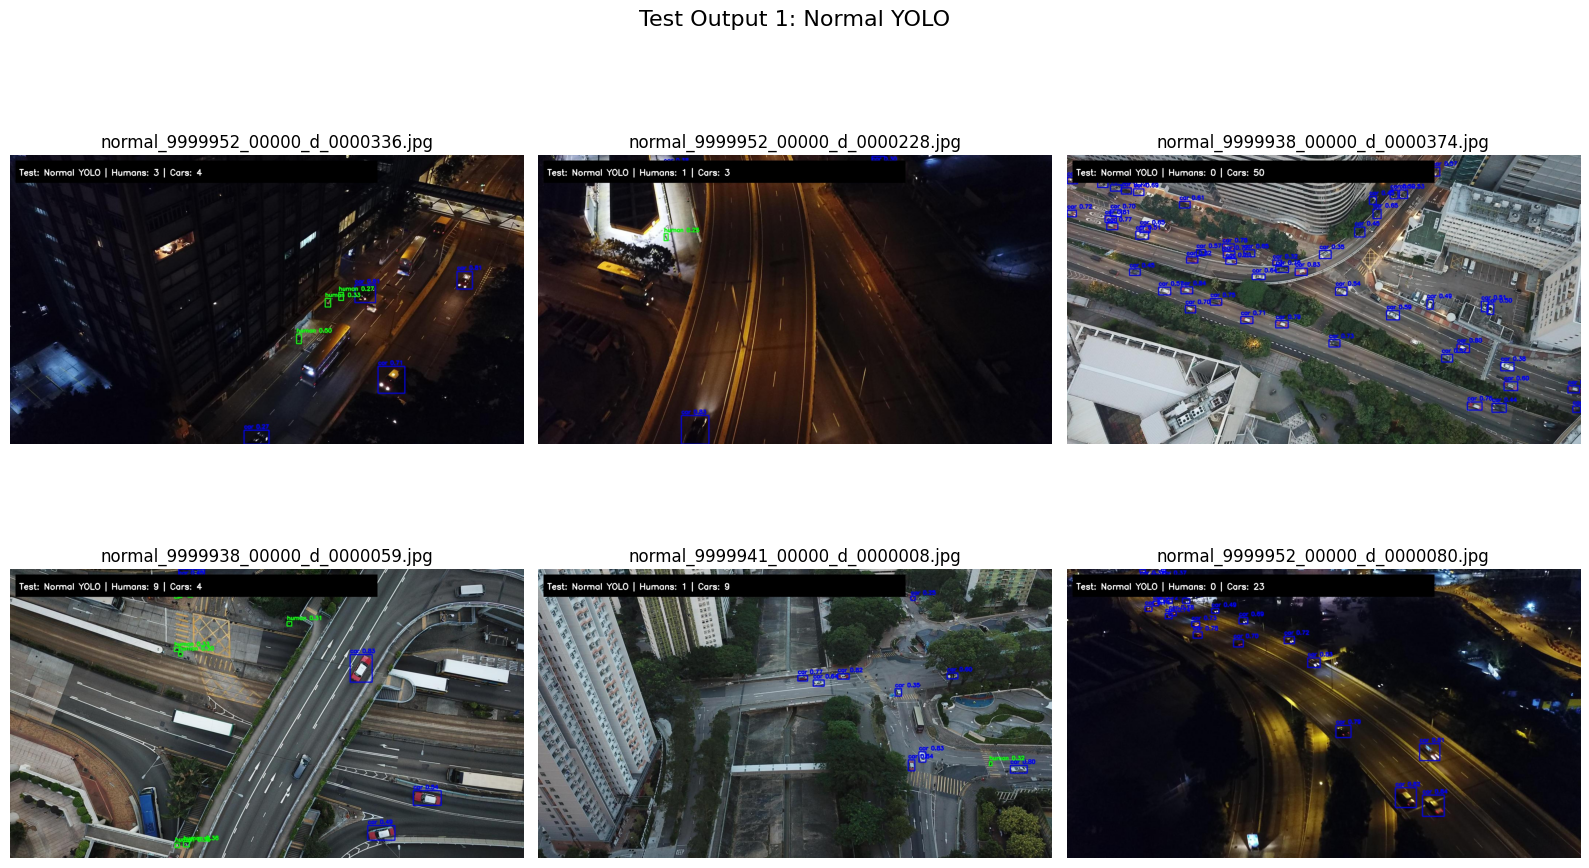

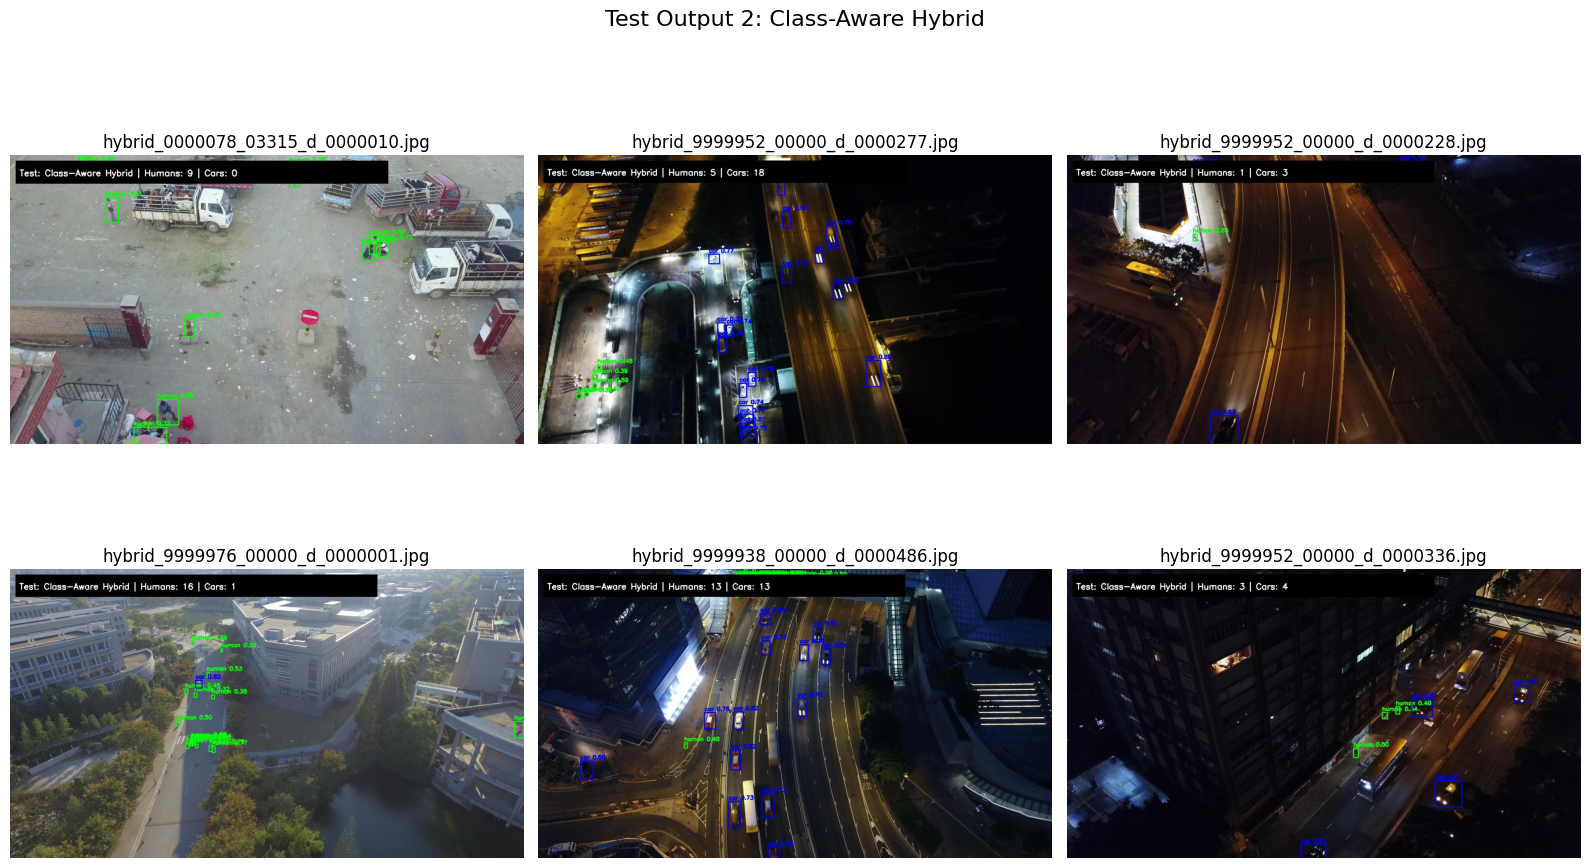

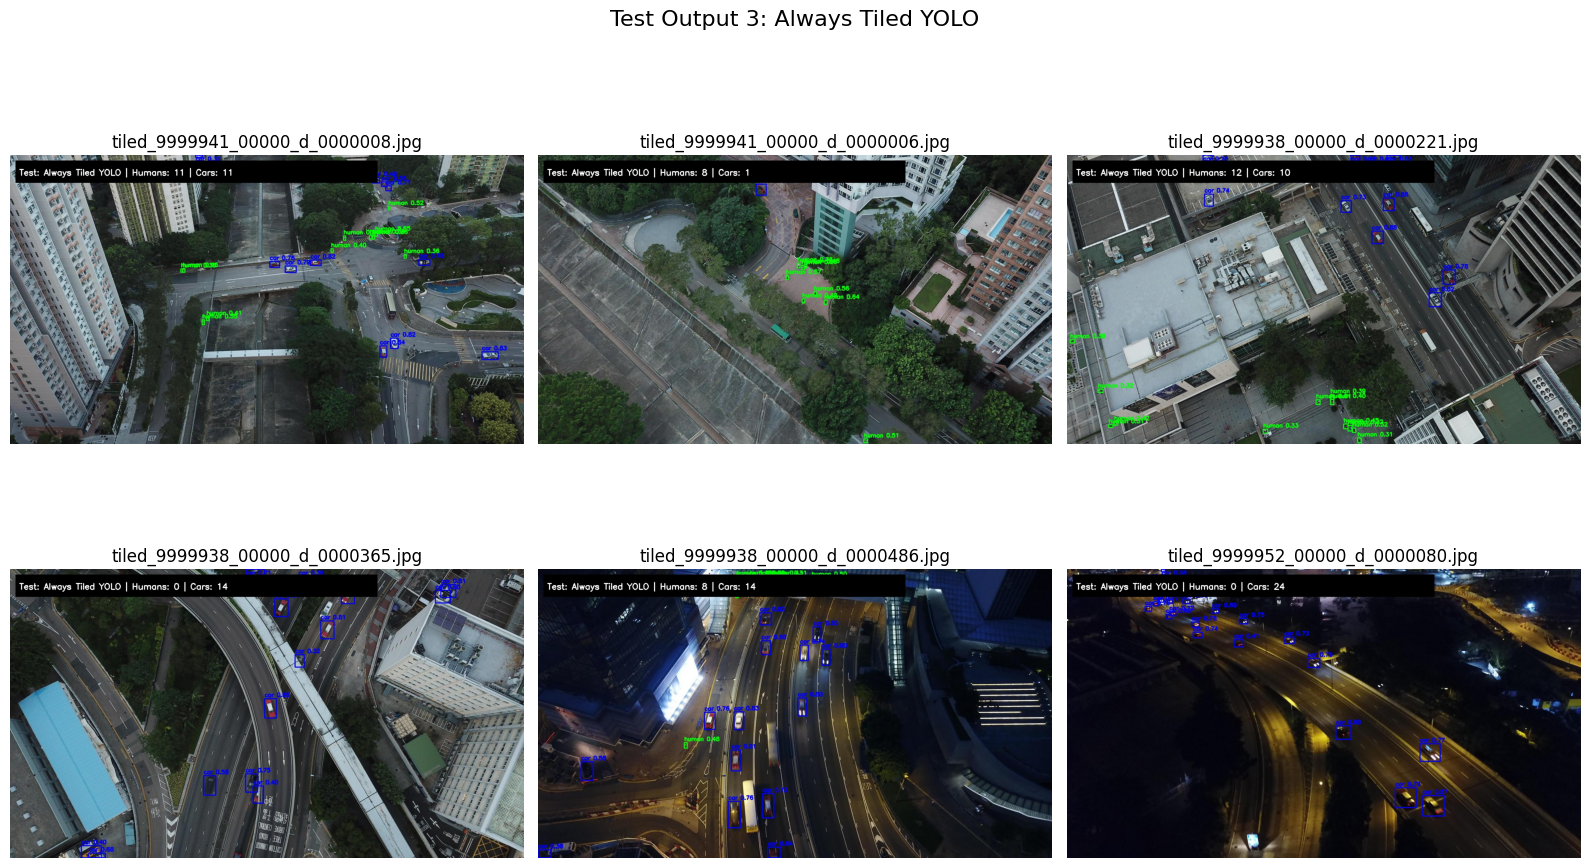

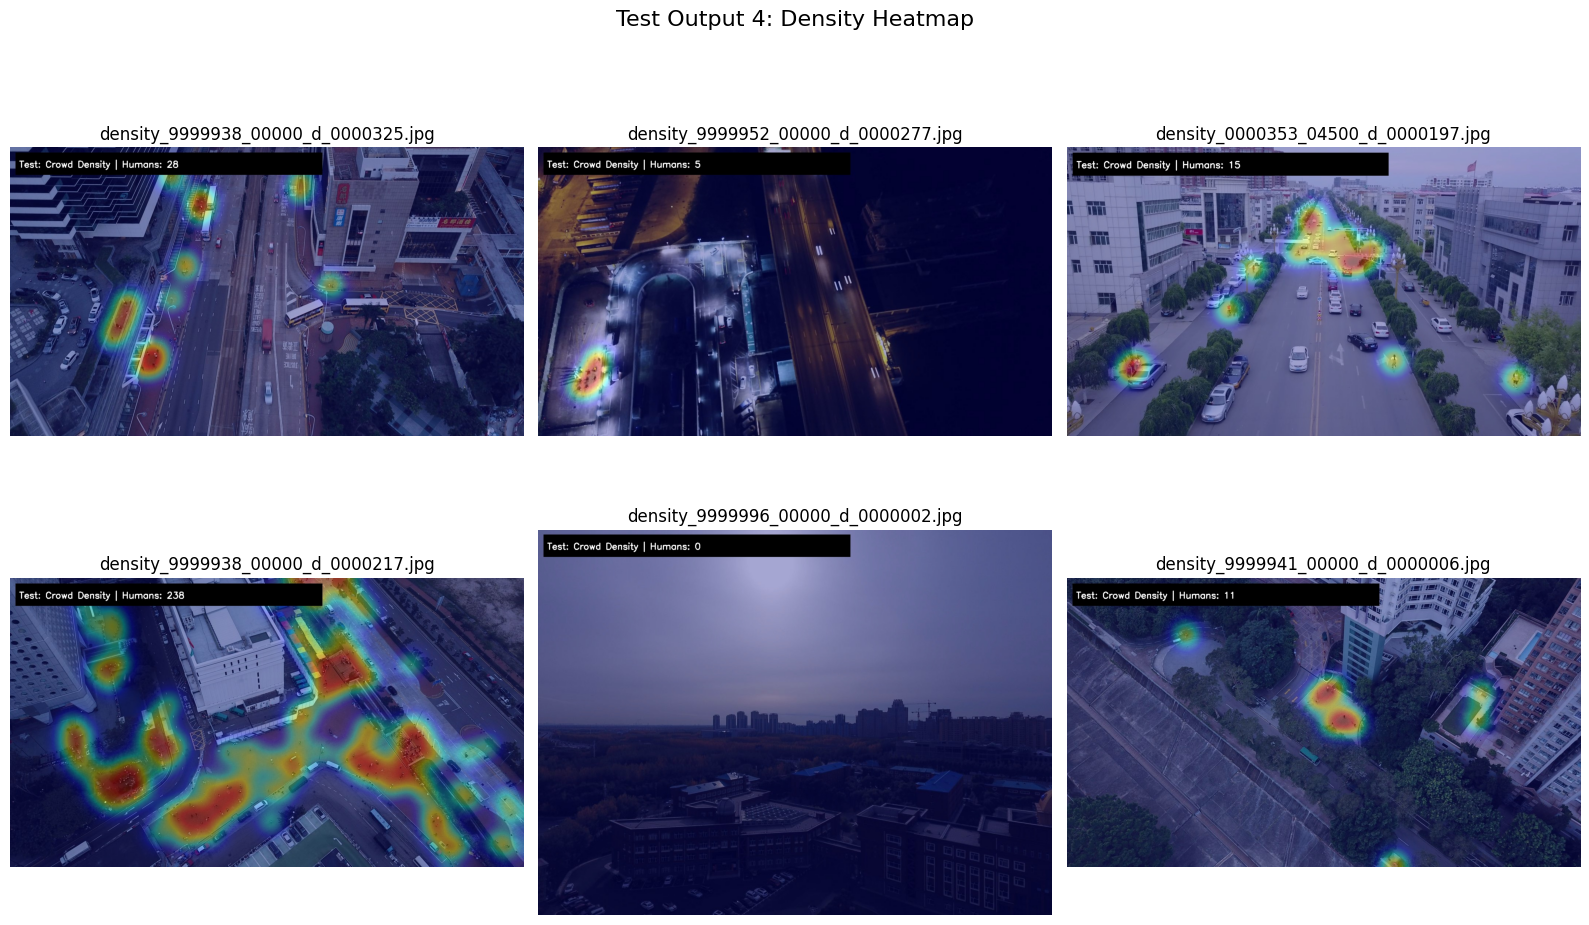

In [22]:
show_images_from_folder(OUTPUT_NORMAL, "Test Output 1: Normal YOLO")
show_images_from_folder(OUTPUT_HYBRID, "Test Output 2: Class-Aware Hybrid")
show_images_from_folder(OUTPUT_TILED, "Test Output 3: Always Tiled YOLO")
show_images_from_folder(OUTPUT_DENSITY, "Test Output 4: Density Heatmap")

In [23]:
ZIP_PATH = "/kaggle/working/test_detection_outputs.zip"

!zip -r {ZIP_PATH} \
/kaggle/working/test_output_1_normal_yolo \
/kaggle/working/test_output_2_class_aware_hybrid \
/kaggle/working/test_output_3_always_tiled_yolo \
/kaggle/working/test_output_4_density_heatmap \
/kaggle/working/test_normal_counts.csv \
/kaggle/working/test_hybrid_counts.csv \
/kaggle/working/test_tiled_counts.csv \
/kaggle/working/test_density_counts.csv \
/kaggle/working/test_detection_comparison.csv

print("Saved:", ZIP_PATH)

  adding: kaggle/working/test_output_1_normal_yolo/ (stored 0%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999952_00000_d_0000336.jpg (deflated 5%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999952_00000_d_0000228.jpg (deflated 5%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999938_00000_d_0000374.jpg (deflated 4%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999938_00000_d_0000059.jpg (deflated 5%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999941_00000_d_0000008.jpg (deflated 5%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999952_00000_d_0000080.jpg (deflated 4%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999938_00000_d_0000325.jpg (deflated 4%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999938_00000_d_0000365.jpg (deflated 5%)
  adding: kaggle/working/test_output_1_normal_yolo/normal_9999938_00000_d_0000135.jpg (deflated 4%)
  adding: kaggle/working/test_output

In [24]:
TEST_LBL_DIR = TEST_DEV_DIR / "labels"

print("Test images:", TEST_IMG_DIR.exists())
print("Test labels:", TEST_LBL_DIR.exists())

Test images: True
Test labels: True


In [25]:
CLASS_MAP = {
    0: 0,  # pedestrian -> human
    1: 0,  # people -> human
    3: 1   # car -> car
}

def filter_and_copy_dataset(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, keep_empty=False):
    image_files = []
    image_files.extend(list(src_img_dir.glob("*.jpg")))
    image_files.extend(list(src_img_dir.glob("*.jpeg")))
    image_files.extend(list(src_img_dir.glob("*.png")))

    kept_images = 0
    kept_objects = 0
    skipped_images = 0

    for img_path in tqdm(image_files):
        label_path = src_lbl_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            skipped_images += 1
            continue

        new_lines = []

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                old_class = int(float(parts[0]))

                if old_class not in CLASS_MAP:
                    continue

                new_class = CLASS_MAP[old_class]

                x_center = parts[1]
                y_center = parts[2]
                width = parts[3]
                height = parts[4]

                new_lines.append(f"{new_class} {x_center} {y_center} {width} {height}")

        if len(new_lines) > 0 or keep_empty:
            shutil.copy(img_path, dst_img_dir / img_path.name)

            with open(dst_lbl_dir / f"{img_path.stem}.txt", "w") as f:
                f.write("\n".join(new_lines))

            kept_images += 1
            kept_objects += len(new_lines)
        else:
            skipped_images += 1

    return kept_images, kept_objects, skipped_images

In [26]:
TEST_PROJECT_DIR = WORK_ROOT / "drone_human_car_test_dataset"

FINAL_TEST_IMG = TEST_PROJECT_DIR / "images/val"
FINAL_TEST_LBL = TEST_PROJECT_DIR / "labels/val"

FINAL_TEST_IMG.mkdir(parents=True, exist_ok=True)
FINAL_TEST_LBL.mkdir(parents=True, exist_ok=True)

test_result = filter_and_copy_dataset(
    TEST_IMG_DIR,
    TEST_LBL_DIR,
    FINAL_TEST_IMG,
    FINAL_TEST_LBL,
    keep_empty=False
)

print("Test result:", test_result)
print("Format: kept_images, kept_objects, skipped_images")

100%|██████████| 1610/1610 [00:47<00:00, 33.95it/s]

Test result: (1603, 55456, 7)
Format: kept_images, kept_objects, skipped_images


In [27]:
TEST_YAML_PATH = TEST_PROJECT_DIR / "test_data.yaml"

test_yaml = {
    "path": str(TEST_PROJECT_DIR),
    "train": "images/val",
    "val": "images/val",
    "names": {
        0: "human",
        1: "car"
    }
}

with open(TEST_YAML_PATH, "w") as f:
    yaml.dump(test_yaml, f)

print(open(TEST_YAML_PATH).read())

names:
  0: human
  1: car
path: /kaggle/working/drone_human_car_test_dataset
train: images/val
val: images/val



In [28]:
DEVICE = 0
IMAGE_SIZE = 960

In [29]:
test_metrics = detector.val(
    data=str(TEST_YAML_PATH),
    imgsz=IMAGE_SIZE,
    conf=NORMAL_CONF,
    device=DEVICE,
    project="/kaggle/working/evaluation",
    name="test_dev_eval"
)

test_precision = float(test_metrics.box.mp)
test_recall = float(test_metrics.box.mr)
test_map50 = float(test_metrics.box.map50)
test_map50_95 = float(test_metrics.box.map)

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test mAP50:", test_map50)
print("Test mAP50-95:", test_map50_95)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2317.7±874.1 MB/s, size: 186.0 KB)
val: Scanning /kaggle/working/drone_human_car_test_dataset/labels/val... 1603 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1603/1603 1.2Kit/s 1.4s
val: New cache created: /kaggle/working/drone_human_car_test_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 1.5it/s 1:08
                   all       1603      55456      0.736      0.603      0.574      0.335
                 human       1267      27382      0.661      0.416       0.39      0.164
                   car       1530      28074      0.811       0.79      0.759      0.506
Speed: 1.2ms preprocess, 33.7ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /kaggle/working/evaluation/test_dev_eval
Test Precision: 0.7360266878750423
Test Recall: 0.60313

In [30]:
# Optional Task-04: ByteTrack Object Tracking

TRACK_OUTPUT_DIR = WORK_ROOT / "test_output_5_bytetrack_tracking"
TRACK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Get test images
all_test_images = sorted(list(TEST_IMG_DIR.glob("*.jpg")))

# Group images by sequence prefix
# Example: 9999938_00000_d_0000112.jpg -> 9999938_00000_d
from collections import defaultdict

sequence_groups = defaultdict(list)

for img_path in all_test_images:
    parts = img_path.stem.split("_")
    sequence_key = "_".join(parts[:-1])
    sequence_groups[sequence_key].append(img_path)

# Select the sequence with the most frames
best_sequence = max(sequence_groups, key=lambda k: len(sequence_groups[k]))
video_frames = sorted(sequence_groups[best_sequence])[:80]

print("Selected sequence:", best_sequence)
print("Number of frames:", len(video_frames))

# Create video from continuous frames
DEMO_VIDEO_PATH = WORK_ROOT / "tracking_input_video.mp4"

first_img = cv2.imread(str(video_frames[0]))
height, width, _ = first_img.shape

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(str(DEMO_VIDEO_PATH), fourcc, 10, (width, height))

for img_path in video_frames:
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (width, height))
    video_writer.write(img)

video_writer.release()

print("Tracking input video saved:", DEMO_VIDEO_PATH)

# Run ByteTrack
tracking_results = detector.track(
    source=str(DEMO_VIDEO_PATH),
    tracker="bytetrack.yaml",
    conf=NORMAL_CONF,
    imgsz=960,
    save=True,
    project=str(TRACK_OUTPUT_DIR),
    name="bytetrack_result",
    persist=True
)

print("Tracking output saved in:", TRACK_OUTPUT_DIR)

Selected sequence: 9999938_00000_d
Number of frames: 80
Tracking input video saved: /kaggle/working/tracking_input_video.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 307ms
 Downloaded lap
Prepared 1 package in 98ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class pro